# Trabajo Práctico Final — Sistema de Detección y Segmentación de Objetos en Tiempo Real
## Notebook 01 · Construcción del conjunto de datos

**Maestría en Inteligencia Artificial — Deep Learning**

---

Este notebook implementa la primera etapa del pipeline: la **construcción del conjunto de datos**. A partir del dataset público **COCO 2017** (*Common Objects in Context*, Lin et al., 2014) se extrae un subconjunto de ocho clases de objetos de entorno doméstico y de oficina. La selección de clases responde a un criterio de aplicación: todas corresponden a objetos que pueden exhibirse físicamente frente a una cámara web, requisito de la demostración de inferencia en tiempo real que integra este trabajo.

Las etapas desarrolladas son:

1. Descarga selectiva de imágenes de COCO 2017 mediante *FiftyOne*.
2. Filtrado de anotaciones para restringir el problema a las clases de interés.
3. Análisis exploratorio del subconjunto resultante.
4. Partición en conjuntos de entrenamiento, validación y prueba.
5. Conversión de las anotaciones al formato YOLO de segmentación y verificación de la exportación.

> **Nota de ejecución:** este notebook está diseñado para ejecutarse en el servidor de entrenamiento (JupyterLab con GPU), de modo que la descarga del subconjunto (~1 GB) y el almacenamiento del dataset se realicen directamente en el entorno donde luego se entrena el modelo.

### 1. Entorno y configuración

Se emplea **FiftyOne** para la descarga selectiva de COCO: en lugar de obtener el dataset completo (118.287 imágenes de entrenamiento, ~19 GB), se descargan únicamente imágenes que contienen al menos una instancia de las clases objetivo, junto con sus anotaciones de **segmentación de instancias** (polígonos). Esta estrategia reduce el volumen de datos en más de un orden de magnitud sin comprometer la validez del experimento.

Se fija una semilla aleatoria global para garantizar la **reproducibilidad** de la selección de imágenes y de las particiones. Las proporciones de partición (60 % / 15 % / 25 %) siguen el esquema utilizado a lo largo del curso.

In [1]:
# Instalación de dependencias (descomentar en la primera ejecución en el servidor)
#%pip install -q fiftyone ultralytics


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /home/federico.moran/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
#%pip install -q pycocotools ipywidgets


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /home/federico.moran/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Polygon as MplPolygon
import numpy as np
import pandas as pd

import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.utils.labels as foul
import fiftyone.utils.random as four
from fiftyone import ViewField as Fhe 

# --- Configuración general del experimento ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Clases objetivo: objetos de escritorio e interior, exhibibles ante una webcam
CLASSES = ['person', 'cell phone', 'cup', 'bottle', 'laptop', 'keyboard', 'mouse', 'book']

MAX_SAMPLES = 5000                                   # imágenes a descargar del split train de COCO
SPLITS = {'train': 0.60, 'val': 0.15, 'test': 0.25}  # proporciones de partición

# --- Rutas del proyecto ---
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'coco_subset'        # dataset en formato YOLO (8 clases)
DATA80_DIR = ROOT / 'data' / 'coco_subset_80'   # partición de prueba con las 80 clases (baseline)

# --- Estilo de los gráficos (paleta categórica de orden fijo) ---
C_AZUL, C_AQUA, C_AMBAR, C_VERDE = '#2a78d6', '#1baf7a', '#eda100', '#008300'
PALETTE8 = ['#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']
CLASS_COLORS = dict(zip(CLASSES, PALETTE8))
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.titlesize': 12, 'font.family': 'sans-serif',
})

print(f'Directorio raíz del proyecto: {ROOT}')
print(f'Clases objetivo ({len(CLASSES)}): {CLASSES}')

Directorio raíz del proyecto: /data/students/federico.moran/TPF - Computer Vision
Clases objetivo (8): ['person', 'cell phone', 'cup', 'bottle', 'laptop', 'keyboard', 'mouse', 'book']


### 2. Descarga del subconjunto de COCO 2017

COCO 2017 contiene 80 categorías de objetos cotidianos anotadas a nivel de instancia mediante polígonos, lo que habilita tanto la tarea de **detección** (cajas delimitadoras) como la de **segmentación de instancias** (máscaras). Se solicita a FiftyOne el split de entrenamiento, restringido a imágenes que contengan al menos una de las clases objetivo, con un máximo de `MAX_SAMPLES` imágenes seleccionadas de forma aleatoria y reproducible.

La primera ejecución descarga las imágenes y anotaciones; ejecuciones posteriores reutilizan la copia local, por lo que la celda es idempotente.

In [2]:
dataset = foz.load_zoo_dataset(
    'coco-2017',
    split='train',
    label_types=['segmentations'],
    classes=CLASSES,
    max_samples=MAX_SAMPLES,
    shuffle=True,
    seed=SEED,
    dataset_name='tpf_coco_subset',
)
dataset.persistent = True
print(dataset)

Found annotations at '/home/federico.moran/fiftyone/coco-2017/raw/instances_train2017.json'
Sufficient images already downloaded
Existing download of split 'train' is sufficient
Loading 'coco-2017' split 'train'
 100% |███████████████| 5000/5000 [1.3m elapsed, 0s remaining, 62.0 samples/s]      
Dataset 'tpf_coco_subset' created
Name:        tpf_coco_subset
Media type:  image
Num samples: 5000
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


### 3. Filtrado de anotaciones

Las imágenes descargadas contienen, además de las clases objetivo, anotaciones de las restantes 72 categorías de COCO (por ejemplo, sillas o mesas presentes en las mismas escenas). Se filtran las etiquetas para conservar **únicamente las instancias de las ocho clases de interés**, lo que define con precisión el alcance del problema: los objetos de otras categorías pasan a formar parte del fondo.

Esta decisión simplifica el modelo y la evaluación, y es coherente con el objetivo del sistema: reconocer un vocabulario acotado de objetos en tiempo real.

In [4]:
view = dataset.filter_labels('ground_truth', Fhe('label').is_in(CLASSES))

n_imgs = view.count()
n_objs = view.count('ground_truth.detections')
print(f'Imágenes en el subconjunto: {n_imgs}')
print(f'Instancias anotadas (8 clases): {n_objs}')
print(f'Promedio de instancias por imagen: {n_objs / n_imgs:.2f}')

Imágenes en el subconjunto: 5000
Instancias anotadas (8 clases): 23363
Promedio de instancias por imagen: 4.67


### 4. Análisis exploratorio

Antes de entrenar es necesario caracterizar el conjunto de datos. Se examinan dos aspectos con impacto directo sobre el entrenamiento y la interpretación de las métricas:

- **Distribución de instancias por clase.** COCO presenta un desbalance natural: la clase *person* domina ampliamente. Este desbalance no se corrige de forma artificial — YOLOv8 lo gestiona adecuadamente mediante su función de pérdida — pero debe tenerse presente al analizar las métricas por clase en la evaluación (Notebook 03).
- **Densidad de objetos por imagen.** Informa sobre la complejidad de las escenas: imágenes con muchas instancias superpuestas son más difíciles tanto para la detección como para la segmentación.

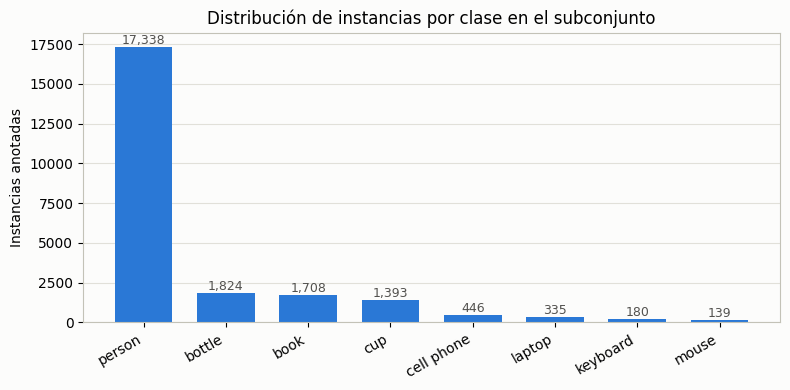

In [5]:
counts = view.count_values('ground_truth.detections.label')
dist = pd.Series(counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color=C_AZUL, width=0.7)
for i, v in enumerate(dist.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9, color='#52514e')
ax.set_ylabel('Instancias anotadas')
ax.set_title('Distribución de instancias por clase en el subconjunto')
ax.grid(axis='x', visible=False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

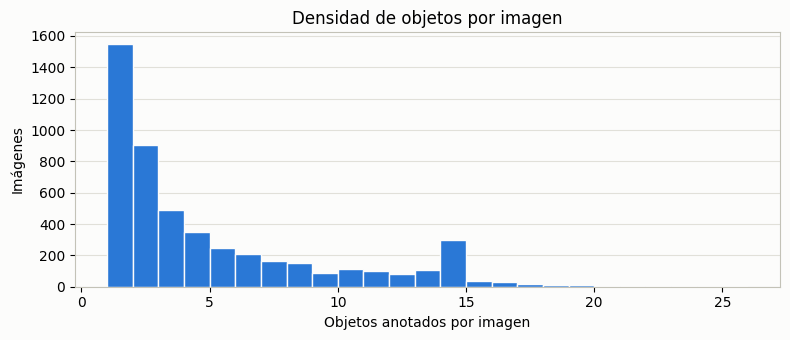

Mediana: 3 objetos/imagen — Máximo: 47


In [7]:
objs_por_imagen = view.values(Fhe('ground_truth.detections').length())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(objs_por_imagen, bins=range(1, 27), color=C_AZUL, edgecolor='#fcfcfb')
ax.set_xlabel('Objetos anotados por imagen')
ax.set_ylabel('Imágenes')
ax.set_title('Densidad de objetos por imagen')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

print(f'Mediana: {np.median(objs_por_imagen):.0f} objetos/imagen — Máximo: {max(objs_por_imagen)}')

### 5. Partición en entrenamiento, validación y prueba

Se divide el subconjunto en tres particiones disjuntas a nivel de imagen, con proporciones **60 % (train) / 15 % (val) / 25 % (test)** y semilla fija:

- **train** — ajuste de los pesos del modelo.
- **val** — monitoreo durante el entrenamiento (selección del mejor punto de control y *early stopping*).
- **test** — evaluación final; esta partición **no interviene en ninguna decisión de entrenamiento**, de modo que las métricas reportadas sobre ella constituyen una estimación no sesgada del desempeño.

Se verifica además que la distribución de clases se mantenga aproximadamente proporcional entre particiones, condición necesaria para que la validación sea representativa del problema.

train    5000
val       750
test     1250


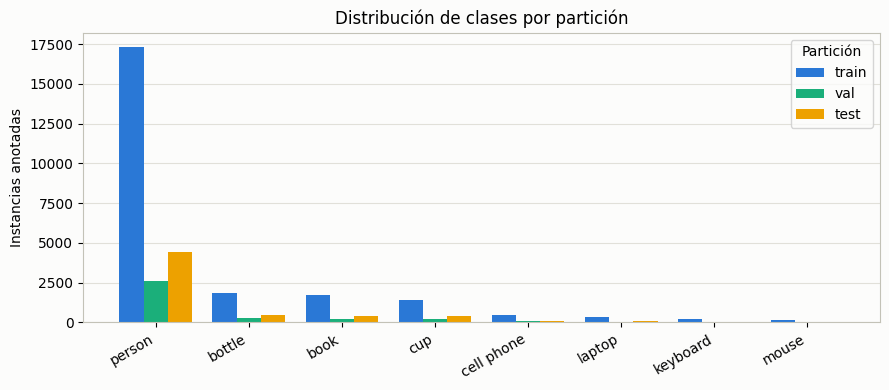

,train,val,test
person,17338,2583,4399
bottle,1824,285,489
book,1708,224,384
cup,1393,206,398
cell phone,446,66,95
laptop,335,38,91
keyboard,180,26,38
mouse,139,15,35


In [8]:
four.random_split(view, SPLITS, seed=SEED)

resumen_splits = pd.Series({s: view.match_tags(s).count() for s in SPLITS}, name='imágenes')
print(resumen_splits.to_string())

# Distribución de clases por partición
filas = []
for split in SPLITS:
    c = view.match_tags(split).count_values('ground_truth.detections.label')
    filas.append(pd.Series(c, name=split))
tabla_clases = pd.DataFrame(filas).T.loc[dist.index]

x = np.arange(len(tabla_clases.index))
w = 0.26
fig, ax = plt.subplots(figsize=(9, 4))
for i, (split, color) in enumerate(zip(tabla_clases.columns, [C_AZUL, C_AQUA, C_AMBAR])):
    ax.bar(x + (i - 1) * w, tabla_clases[split], width=w, label=split, color=color)
ax.set_xticks(x)
ax.set_xticklabels(tabla_clases.index, rotation=30, ha='right')
ax.set_ylabel('Instancias anotadas')
ax.set_title('Distribución de clases por partición')
ax.grid(axis='x', visible=False)
ax.legend(title='Partición')
plt.tight_layout()
plt.show()

tabla_clases

### 6. Conversión al formato YOLO de segmentación

El entrenamiento con Ultralytics requiere las anotaciones en **formato YOLO de segmentación**: un archivo de texto por imagen donde cada línea describe una instancia como

```
<índice_de_clase> x1 y1 x2 y2 ... xn yn
```

con los vértices del polígono normalizados al rango [0, 1] respecto de las dimensiones de la imagen.

La conversión comprende dos pasos:

1. **De máscaras a polilíneas** — las instancias de COCO cargadas por FiftyOne se representan como máscaras binarias; se convierten a polígonos mediante `instances_to_polylines`, con una tolerancia de simplificación de 2 píxeles que reduce el número de vértices sin pérdida perceptible de fidelidad geométrica.
2. **Exportación por partición** — cada partición se exporta al mismo directorio en la estructura estándar (`images/<split>`, `labels/<split>`), generando el archivo `dataset.yaml` que consume el entrenador.

In [9]:
# Paso 1: conversión de máscaras de instancia a polilíneas
foul.instances_to_polylines(view, 'ground_truth', 'polylines', tolerance=2)

# Paso 2: exportación de las tres particiones en formato YOLO
for split in SPLITS:
    view.match_tags(split).export(
        export_dir=str(DATA_DIR),
        dataset_type=fo.types.YOLOv5Dataset,
        label_field='polylines',
        split=split,
        classes=CLASSES,
    )

print('Dataset exportado en:', DATA_DIR)
print('\nContenido de dataset.yaml:\n')
print((DATA_DIR / 'dataset.yaml').read_text())

 100% |███████████████| 5000/5000 [1.8m elapsed, 0s remaining, 40.6 samples/s]      
 100% |███████████████| 5000/5000 [31.6s elapsed, 0s remaining, 155.6 samples/s]      
Directory '/data/students/federico.moran/TPF - Computer Vision/data/coco_subset' already exists; export will be merged with existing files
 100% |█████████████████| 750/750 [4.8s elapsed, 0s remaining, 148.6 samples/s]      
Directory '/data/students/federico.moran/TPF - Computer Vision/data/coco_subset' already exists; export will be merged with existing files
 100% |███████████████| 1250/1250 [8.1s elapsed, 0s remaining, 166.9 samples/s]      
Dataset exportado en: /data/students/federico.moran/TPF - Computer Vision/data/coco_subset

Contenido de dataset.yaml:

names:
  0: person
  1: cell phone
  2: cup
  3: bottle
  4: laptop
  5: keyboard
  6: mouse
  7: book
path: /data/students/federico.moran/TPF - Computer Vision/data/coco_subset
test: ./images/test/
train: ./images/train/
val: ./images/val/



### 7. Exportación adicional para la evaluación del modelo de referencia (baseline)

En el Notebook 03 se comparará el modelo ajustado (*fine-tuned*) contra el modelo preentrenado original `yolov8n-seg.pt`, que predice las **80 clases de COCO con sus índices originales**. Para poder evaluarlo con `model.val()` es necesario que los índices de clase de las etiquetas coincidan con los del modelo; por ello se exporta una **segunda copia de la partición de prueba** cuyas etiquetas usan el vocabulario completo de 80 clases.

> **Nota técnica:** esta copia se registra bajo la clave `val` del `dataset.yaml` correspondiente, dado que es la clave que la rutina de validación de Ultralytics espera por defecto. Su contenido es, no obstante, la partición de **prueba** definida en la sección 5.

In [10]:
# Vocabulario COCO de 80 clases en el orden canónico usado por los modelos YOLOv8
COCO80 = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
    'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush',
]

view.match_tags('test').export(
    export_dir=str(DATA80_DIR),
    dataset_type=fo.types.YOLOv5Dataset,
    label_field='polylines',
    split='val',   # registrada como val por compatibilidad con model.val(); contiene la partición de prueba
    classes=COCO80,
)
print('Partición de prueba (80 clases) exportada en:', DATA80_DIR)

 100% |███████████████| 1250/1250 [8.1s elapsed, 0s remaining, 166.3 samples/s]       
Partición de prueba (80 clases) exportada en: /data/students/federico.moran/TPF - Computer Vision/data/coco_subset_80


#### 7.1 Saneamiento de etiquetas degeneradas

Las máscaras de objetos muy pequeños pueden degenerar, tras la simplificación poligonal (sección 6), en polígonos de menos de tres vértices. En el formato YOLO esas líneas quedan con cuatro coordenadas — el formato de una caja de detección — y el cargador de Ultralytics, al encontrar una mezcla de cajas y polígonos, rechaza el dataset de segmentación completo.

Se eliminan dichas líneas de los archivos exportados (en ambas copias del dataset). Su incidencia es despreciable — del orden del 0,01 % de las instancias — y corresponde a objetos cuya máscara carece de área significativa, por lo que su eliminación no afecta la validez del conjunto de datos.

In [12]:
eliminadas = 0
for lbl in (ROOT / 'data').glob('coco_subset*/labels/*/*.txt'):
    lineas = lbl.read_text().strip().splitlines()
    validas = [l for l in lineas if len(l.split()) >= 7]   # clase + al menos 3 vértices
    if len(validas) != len(lineas):
        eliminadas += len(lineas) - len(validas)
        lbl.write_text(('\n'.join(validas) + '\n') if validas else '')

# Se invalidan las cachés de etiquetas de Ultralytics, si existieran de una corrida previa
for cache in (ROOT / 'data').glob('coco_subset*/labels/*.cache'):
    cache.unlink()

print(f'Líneas degeneradas eliminadas: {eliminadas}')

Líneas degeneradas eliminadas: 1314


### 8. Verificación de la exportación

Como control de calidad se reconstruyen las anotaciones **a partir de los archivos exportados** (no de los objetos en memoria) y se superponen sobre las imágenes correspondientes. Este paso valida la cadena completa de conversión: si los polígonos dibujados coinciden con los objetos, el formato, la normalización de coordenadas y la asignación de índices de clase son correctos.

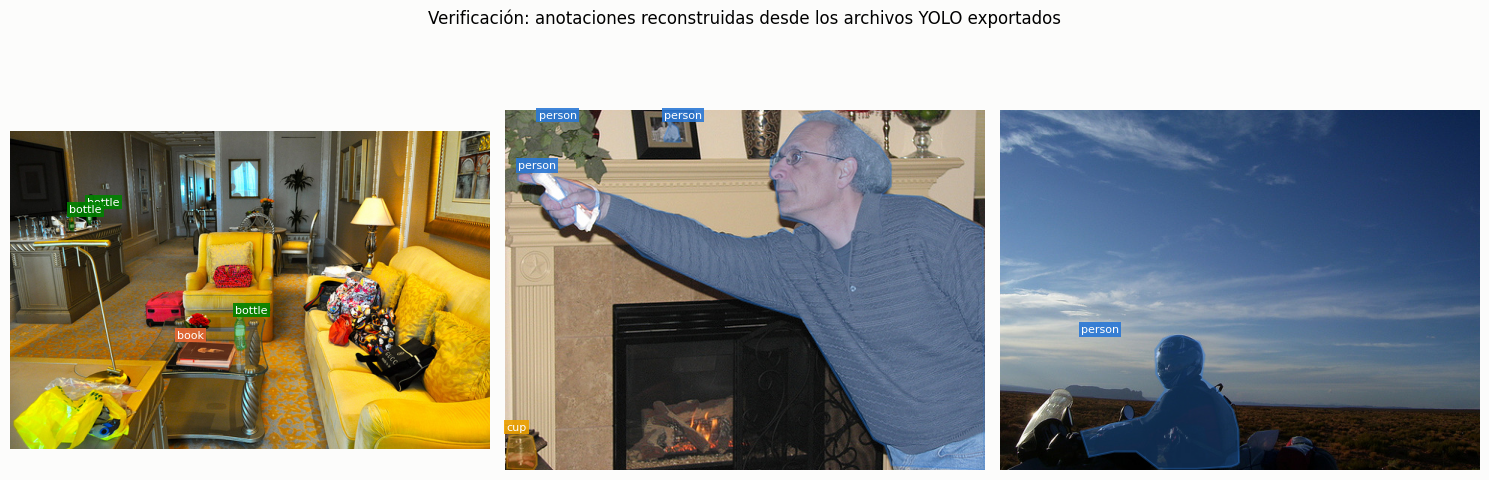

In [13]:
img_dir = DATA_DIR / 'images' / 'train'
lbl_dir = DATA_DIR / 'labels' / 'train'

ejemplos = random.sample(sorted(lbl_dir.glob('*.txt')), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, lbl_path in zip(axes, ejemplos):
    img_path = img_dir / (lbl_path.stem + '.jpg')
    img = mpimg.imread(img_path)
    h, w = img.shape[:2]
    ax.imshow(img)
    for linea in lbl_path.read_text().strip().splitlines():
        valores = linea.split()
        clase = CLASSES[int(valores[0])]
        pts = np.array(valores[1:], dtype=float).reshape(-1, 2) * [w, h]
        color = CLASS_COLORS[clase]
        ax.add_patch(MplPolygon(pts, closed=True, facecolor=color, alpha=0.35,
                                edgecolor=color, linewidth=1.5))
        ax.text(pts[:, 0].min(), max(pts[:, 1].min() - 4, 8), clase, fontsize=8,
                color='white', bbox=dict(facecolor=color, alpha=0.9, pad=1.5, edgecolor='none'))
    ax.set_axis_off()
fig.suptitle('Verificación: anotaciones reconstruidas desde los archivos YOLO exportados', y=0.98)
plt.tight_layout()
plt.show()

### 9. Síntesis y próximos pasos

En este notebook se construyó el conjunto de datos del trabajo:

- Subconjunto de **COCO 2017** restringido a 8 clases de objetos de interior, con anotaciones de segmentación de instancias.
- Particiones reproducibles train/val/test (60/15/25) con distribución de clases consistente entre particiones.
- Exportación en **formato YOLO de segmentación** (`data/coco_subset/dataset.yaml`), verificada visualmente.
- Copia auxiliar de la partición de prueba con el vocabulario completo de 80 clases (`data/coco_subset_80/`), destinada a la evaluación del modelo de referencia.

El **Notebook 02** utiliza `data/coco_subset/dataset.yaml` para realizar el ajuste fino (*fine-tuning*) de YOLOv8n-seg sobre estas ocho clases.